# 04 — SARIMAX Models

Part 4: AIC grid search for order selection, residual diagnostics, rolling forecast with confidence intervals — target-only and with exogenous weather covariates. Fitting SARIMAX takes ~3 minutes per model, so this notebook displays the already-computed results (from `scripts/run_sarimax.py` / `run_sarimax_exog.py`) rather than refitting live — see those scripts for the full fitting code.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
from IPython.display import Image, display


## Order selection: AIC grid search (147 combinations)

In [2]:
grid = pd.read_csv('../outputs/metrics/sarimax_grid_search.csv')
grid.sort_values('aic').head(10)

,p,d,q,seasonal_order,aic,bic,converged,fit_seconds,error
13,0,1,6,"(1, 1, 1, 24)",7241.507164,7286.489985,False,10.8,NaN
34,1,1,6,"(1, 1, 1, 24)",7245.753652,7295.234756,False,15.2,NaN
6,0,0,6,"(1, 1, 1, 24)",7245.864787,7290.862657,False,11.4,NaN
126,6,0,0,"(1, 1, 1, 24)",7246.229142,7291.242039,True,8.4,NaN
12,0,1,5,"(1, 1, 1, 24)",7250.790546,7291.288629,True,7.9,NaN
105,5,0,0,"(1, 1, 1, 24)",7254.062581,7294.587691,True,9.3,NaN
25,1,0,4,"(1, 1, 1, 24)",7254.577934,7295.103044,False,9.2,NaN
5,0,0,5,"(1, 1, 1, 24)",7259.059345,7299.570952,False,9.4,NaN
67,3,0,4,"(1, 1, 1, 24)",7259.599450,7309.130141,False,10.3,NaN
11,0,1,4,"(1, 1, 1, 24)",7261.655318,7297.665635,True,6.8,NaN


The lowest-AIC results here include some non-converged fits (fast grid search used a capped iteration budget) — the actual chosen order, `(1,1,6)`, was confirmed by refitting the top candidates with a much higher iteration budget. See `report.md` Section 6 for the full story.

## Final model summary (target-only)

In [3]:
print(open('../outputs/model_objects/sarimax_summary.txt').read())

order: (1, 1, 6)
seasonal_order: (1, 1, 1, 24)
trend: c
aic: 32486.45
bic: 32552.14
converged: True

params:
intercept    7.646693e-09
ar.L1        9.133572e-01
ma.L1       -1.607101e+00
ma.L2        6.050616e-01
ma.L3        5.353905e-02
ma.L4       -2.405272e-01
ma.L5        2.066480e-01
ma.L6       -1.748511e-02
ar.S.L24    -1.141337e-02
ma.S.L24    -9.400670e-01
sigma2       5.996550e+03



## Residual diagnostics

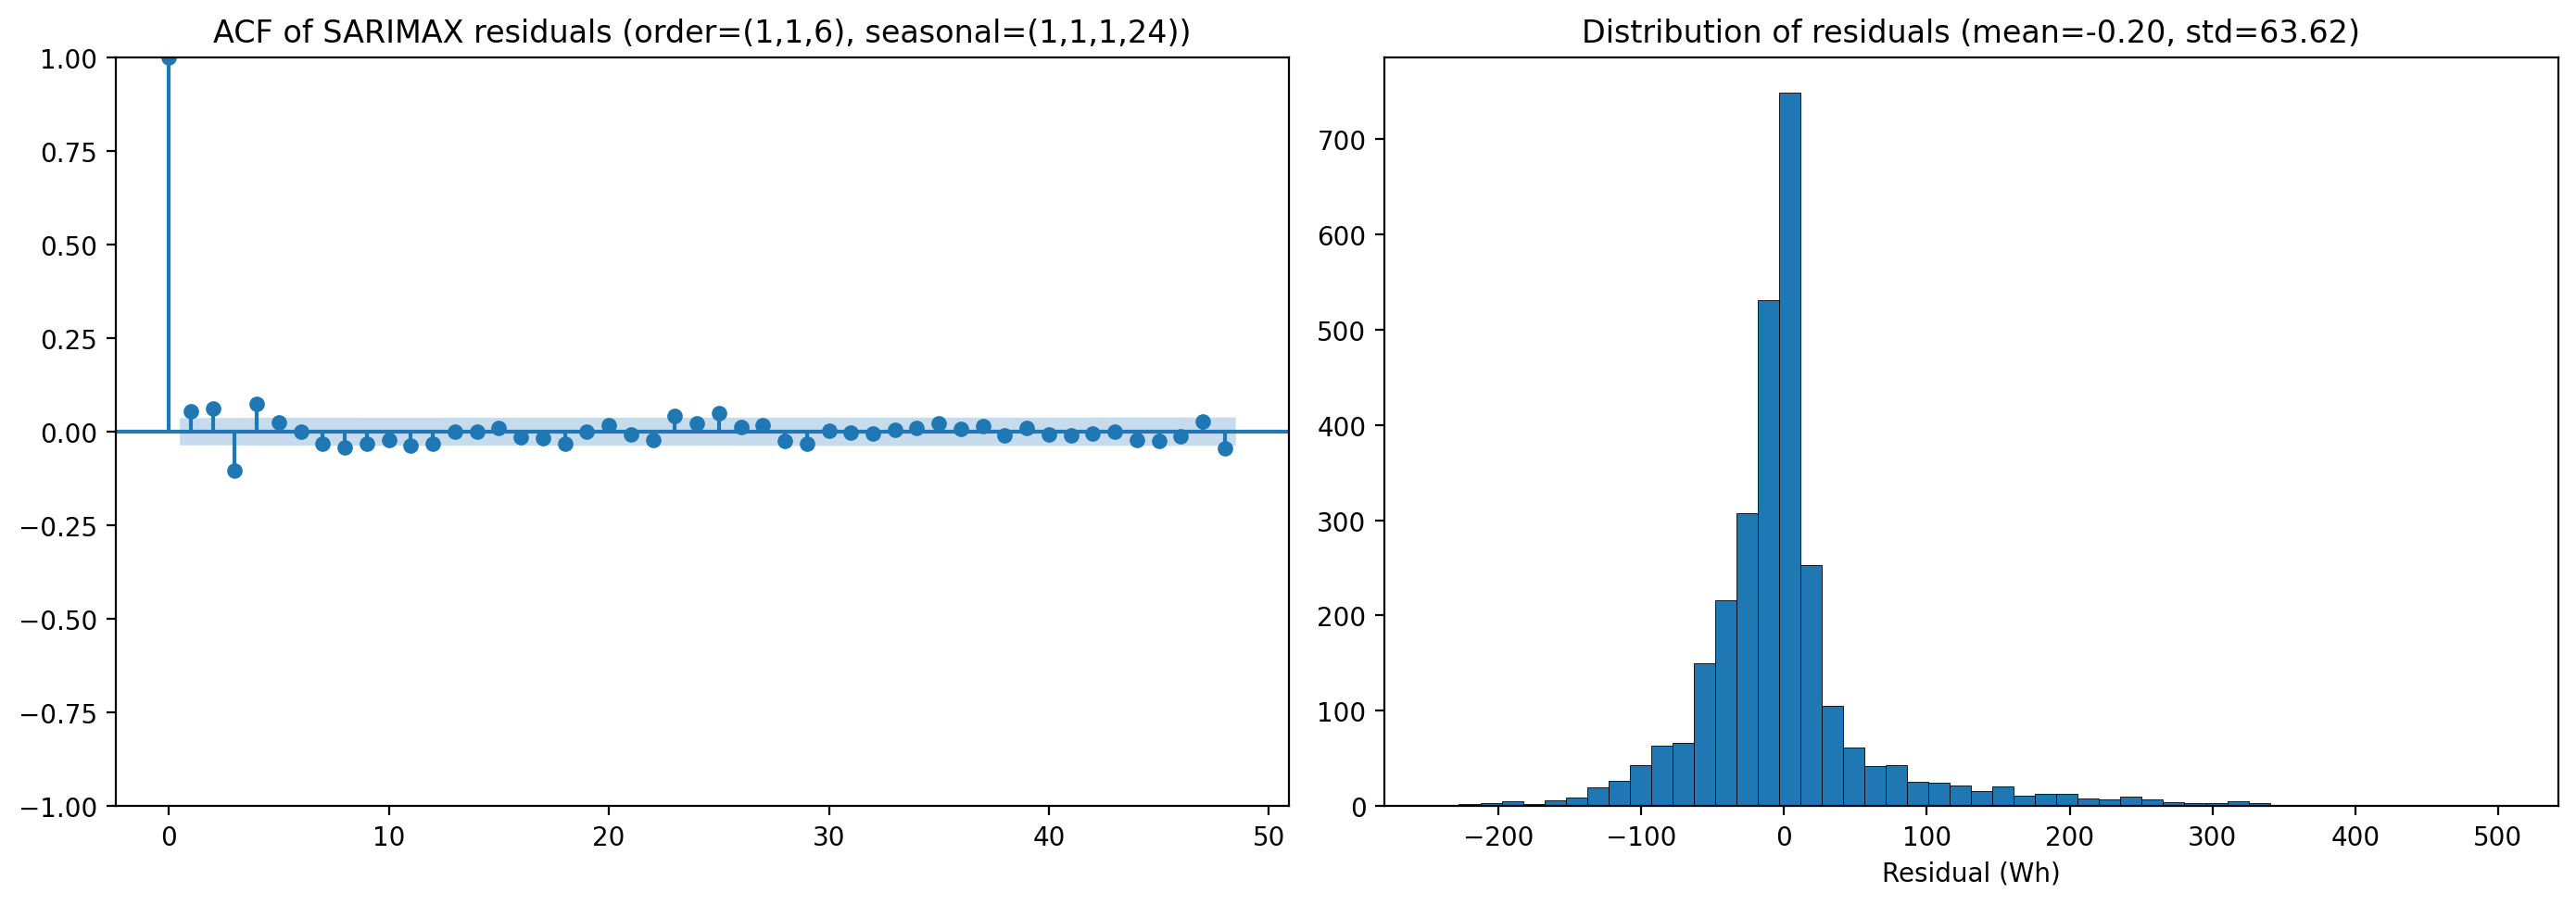

In [4]:
display(Image(filename='../outputs/figures/sarimax_residual_diagnostics.png'))

## Rolling forecast with 95% CI

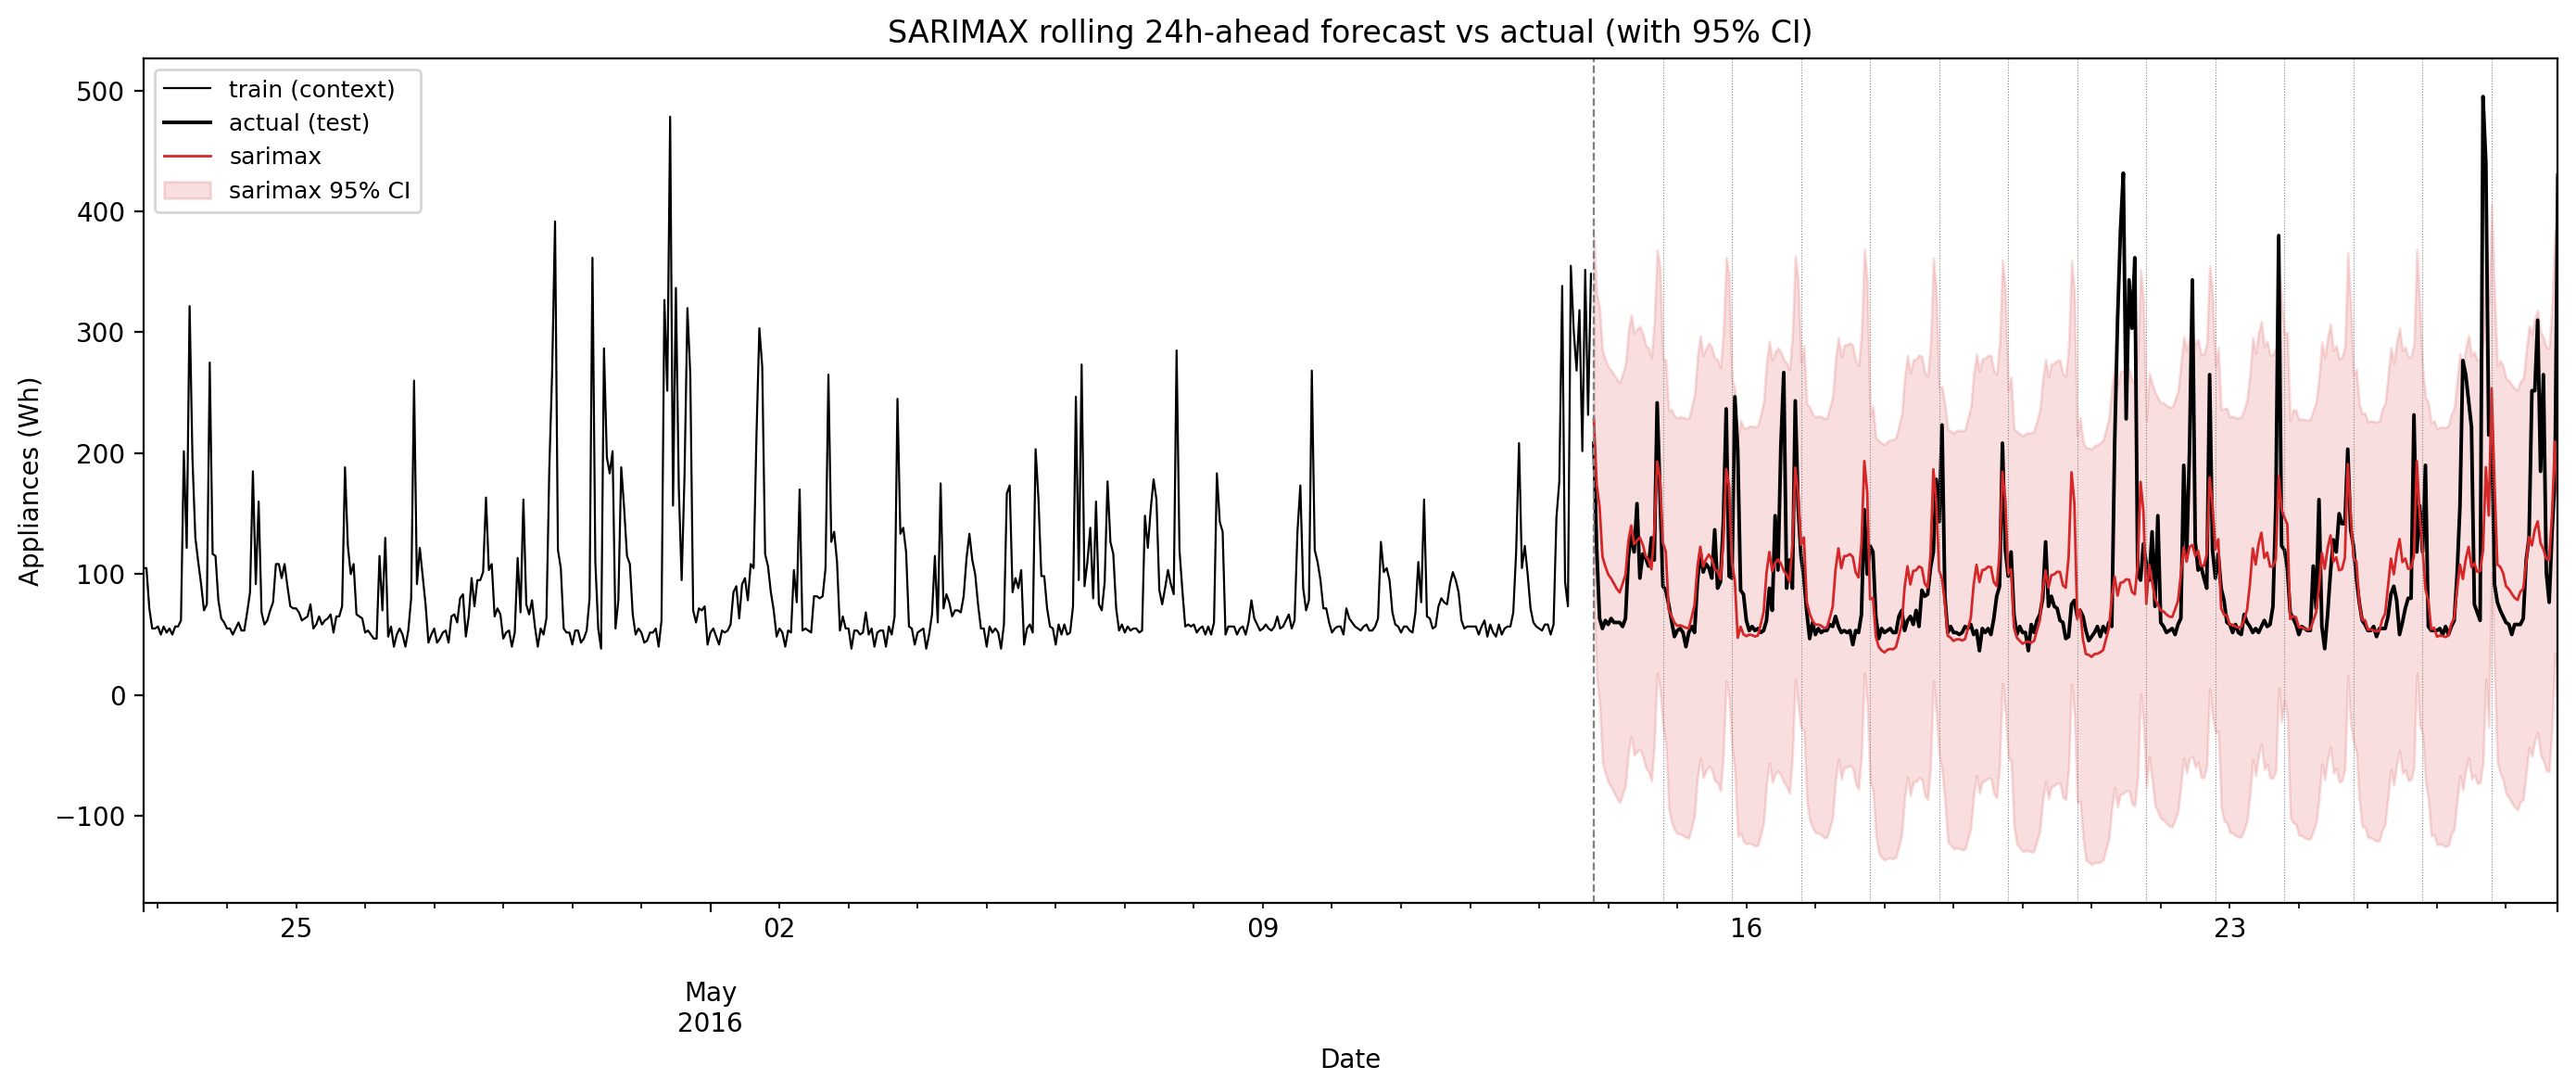

In [5]:
display(Image(filename='../outputs/figures/sarimax_forecast.png'))

## With exogenous weather variables

In [6]:
print(open('../outputs/model_objects/sarimax_exog_summary.txt').read())

order: (1, 1, 6)
seasonal_order: (1, 1, 1, 24)
exog: ['T_out', 'RH_out', 'Windspeed']
trend: c
aic: 32351.59
bic: 32435.19
converged: True

params:
intercept       0.000006
T_out          -0.686216
RH_out          1.135021
Windspeed       0.887102
ar.L1           0.948489
ma.L1          -1.537673
ma.L2           0.421646
ma.L3           0.022500
ma.L4           0.080376
ma.L5          -0.076860
ma.L6           0.090042
ar.S.L24       -0.037254
ma.S.L24       -0.979715
sigma2       4943.580208



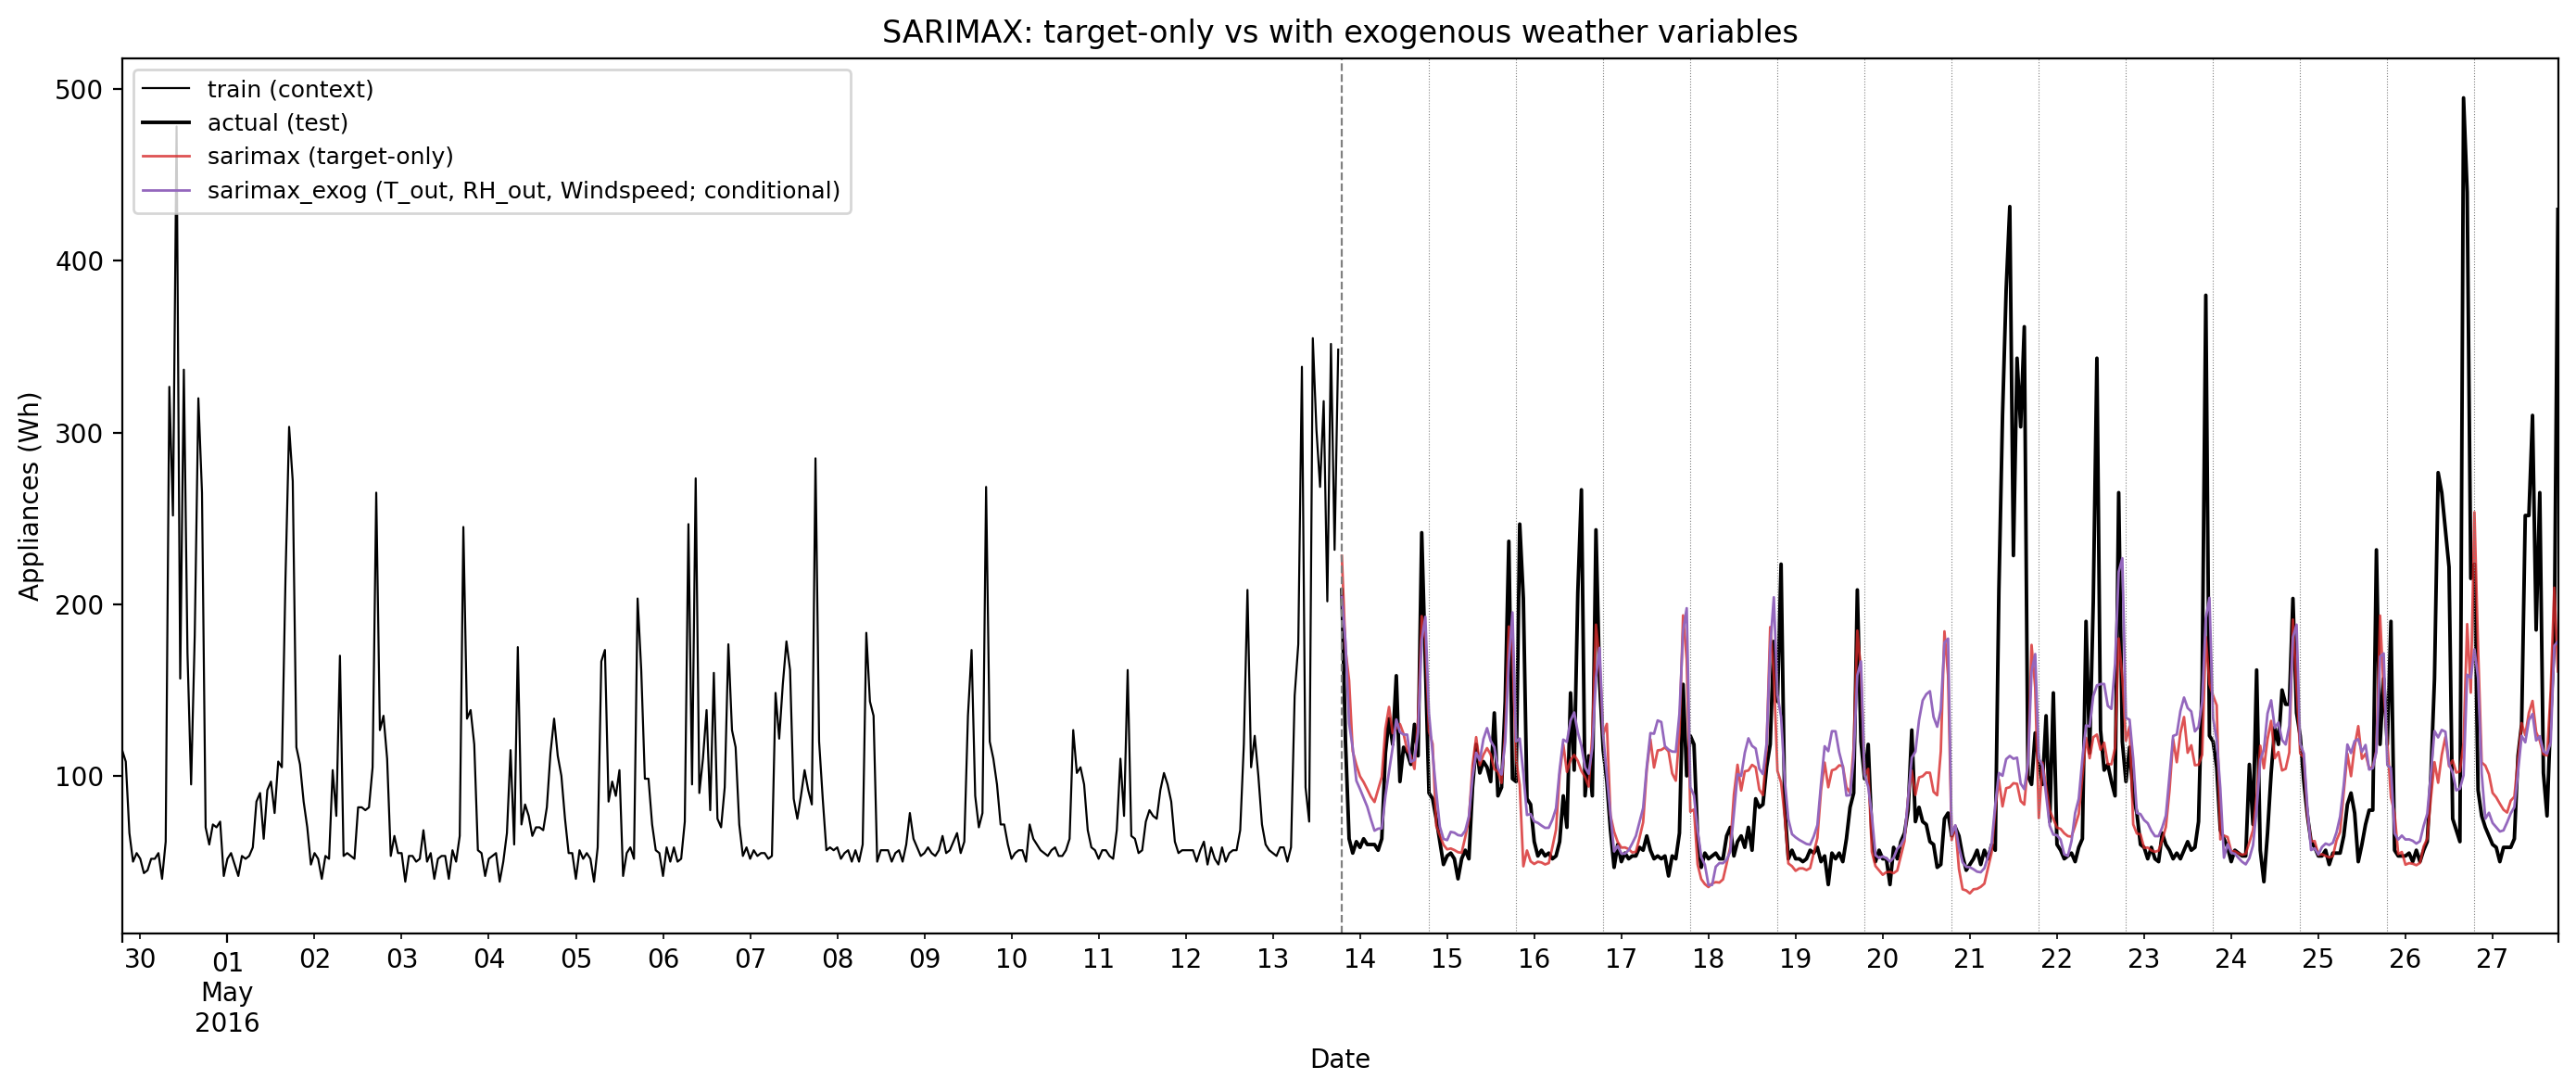

In [7]:
display(Image(filename='../outputs/figures/sarimax_exog_comparison.png'))

## Results

In [8]:
comparison = pd.read_csv('../outputs/metrics/model_comparison.csv')
comparison[comparison['model'].isin(['sarimax', 'sarimax_exog', 'seasonal_naive_weekly'])]

,model,MAE,RMSE,MASE,Bias
0,sarimax,38.055428,65.734392,0.943346,-4.972041
2,sarimax_exog,39.687362,65.778199,0.983800,1.458044
4,seasonal_naive_weekly,43.457341,81.408880,1.077253,-13.159722
